tensor([1.0000, 0.9900, 0.9800, 0.9700, 0.9600, 0.9500, 0.9400, 0.9300, 0.9200,
        0.9100, 0.9000, 0.8900, 0.8800, 0.8700, 0.8600, 0.8500, 0.8400, 0.8300,
        0.8200, 0.8100, 0.8000, 0.7900, 0.7800, 0.7700, 0.7600, 0.7500, 0.7400,
        0.7300, 0.7200, 0.7100, 0.7000, 0.6900, 0.6800, 0.6700, 0.6600, 0.6500,
        0.6400, 0.6300, 0.6200, 0.6100, 0.6000, 0.5900, 0.5800, 0.5700, 0.5600,
        0.5500, 0.5400, 0.5300, 0.5200, 0.5100, 0.5000, 0.4900, 0.4800, 0.4700,
        0.4600, 0.4500, 0.4400, 0.4300, 0.4200, 0.4100, 0.4000, 0.3900, 0.3800,
        0.3700, 0.3600, 0.3500, 0.3400, 0.3300, 0.3200, 0.3100, 0.3000, 0.2900,
        0.2800, 0.2700, 0.2600, 0.2500, 0.2400, 0.2300, 0.2200, 0.2100, 0.2000,
        0.1900, 0.1800, 0.1700, 0.1600, 0.1500, 0.1400, 0.1300, 0.1200, 0.1100,
        0.1000, 0.0900, 0.0800, 0.0700, 0.0600, 0.0500, 0.0400, 0.0300, 0.0200,
        0.0100])
tensor([1.0000, 0.9980, 0.9959, 0.9939, 0.9917, 0.9896, 0.9874, 0.9852, 0.9829,
        0.9806, 0.9783,

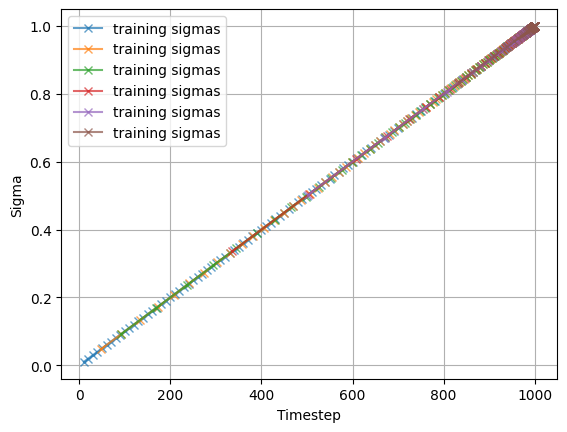

In [42]:
import torch as th
import matplotlib.pyplot as plt

def set_timesteps_wan(num_inference_steps=100, denoising_strength=1.0, shift=None):
    sigma_min = 0.0
    sigma_max = 1.0
    shift = 5 if shift is None else shift
    num_train_timesteps = 1000
    sigma_start = sigma_min + (sigma_max - sigma_min) * denoising_strength
    sigmas = th.linspace(sigma_start, sigma_min, num_inference_steps + 1)[:-1]
    sigmas = shift * sigmas / (1 + (shift - 1) * sigmas)
    timesteps = sigmas * num_train_timesteps
    return sigmas, timesteps

def set_training_weight(timesteps):
    steps = 1000
    x = timesteps
    y = th.exp(-2 * ((x - steps / 2) / steps) ** 2)
    y_shifted = y - y.min()
    bsmntw_weighing = y_shifted * (steps / y_shifted.sum())
    return bsmntw_weighing

# sigmas, timesteps = set_timesteps_wan(num_inference_steps=1000, shift=500)
for shift in [1, 5, 10, 50, 100, 500]:
    sigmas_training, timesteps_training = set_timesteps_wan(100, shift=shift)
    training_weight = set_training_weight(timesteps_training)
    # print(sigmas)
    print(sigmas_training)
    # print(th.allclose(sigmas, sigmas_training))
# plt.plot(timesteps.numpy(), sigmas.numpy())
    # plt.plot(timesteps_training.numpy(), training_weight.numpy(), linestyle='--', alpha=0.5, label='training weight')
    plt.plot(timesteps_training.numpy(), sigmas_training.numpy(), 'x-', alpha=0.7, label='training sigmas')
plt.xlabel("Timestep")
plt.ylabel("Sigma")
plt.legend()
plt.grid()
plt.show()
